# Lab: Simple Linear Regression with scikit-learn
In the [theory notes](./02_simple_linear_regression_theory.md), we learned *what* Simple Linear Regression is and *how* it works mathematically. In the [implementation file](./03_simple_linear_regression_implementation.py), we built it from scratch using only NumPy to solidify our understanding of the underlying mechanics.

**Now it's time to see how the real world does it.** In practice, nobody implements regression from scratch — we use battle-tested libraries. In this lab, we will learn how to:

1.  Load and prepare a dataset for modeling.
2.  Build a Simple Linear Regression model using **scikit-learn**.
3.  Interpret the model's coefficients.
4.  Use the model to make predictions.
5.  Visualize the regression line against the data.

---

## 1. The Dataset

We'll use a classic **Advertising** dataset. It contains data from 200 different markets, showing spending on TV, Radio, and Newspaper ads, alongside resulting Sales. Since this is a *simple* linear regression lab, we'll focus on a single relationship: **TV advertising spend → Sales**.

Let's start by importing our libraries and loading the data.

In [40]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150

In [43]:
# Load the data
data = pd.read_csv("../data/raw/advertising.csv")

# Drop the unnecessary 'Unnamed: 0' column
data = data.drop(columns=["Unnamed: 0"])

# Take a look at the first 5 rows
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [44]:
# Display general information about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


Good — 200 rows, no missing values, and all numerical columns. Since we're doing *simple* linear regression, we only need `TV` and `Sales`.

---

## 2. Preparing the Data

Let's keep only the columns we need and do some light cleanup.

In [45]:
# Keep only TV and Sales
sales_df = data[["TV", "Sales"]].copy()

# Convert column names to lower case for consistency
sales_df.columns = [col.lower() for col in sales_df.columns]

# Quick sanity checks
print(f"Shape: {sales_df.shape}")
print(f"Duplicated rows: {sales_df.duplicated().sum()}")
print(f"Missing values:\n{sales_df.isnull().sum()}")

Shape: (200, 2)
Duplicated rows: 0
Missing values:
tv       0
sales    0
dtype: int64


No duplicates, no missing values — the data is clean and ready to go.

---

## 3. Exploring the Data

Before fitting a model, let's explore the data visually to see if a linear relationship even makes sense.

In [46]:
# Descriptive statistics
sales_df.describe()

,tv,sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


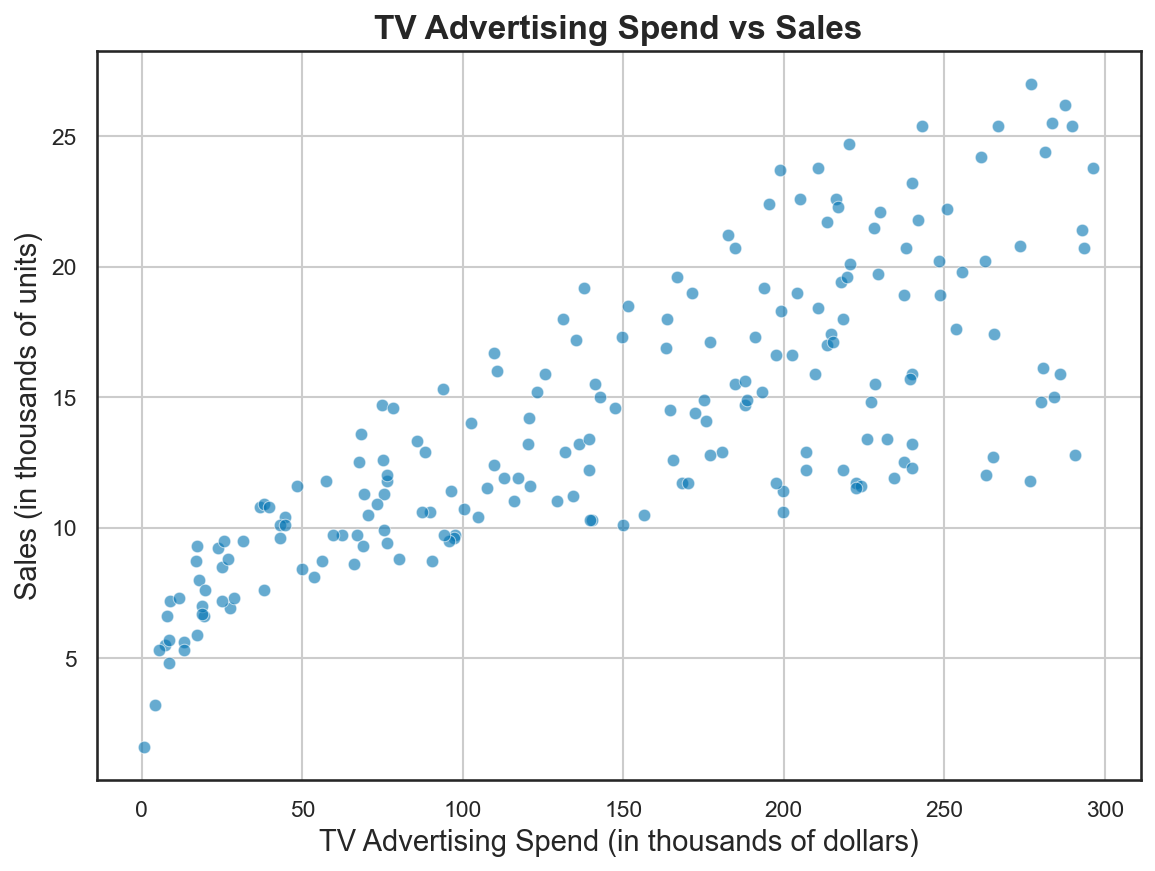

In [47]:
# Scatter plot of TV vs Sales
plt.figure()
sns.scatterplot(data=sales_df, x="tv", y="sales", alpha=0.6)
plt.title("TV Advertising Spend vs Sales", fontsize=16, fontweight='bold')
plt.xlabel("TV Advertising Spend (in thousands of dollars)", fontsize=14)
plt.ylabel("Sales (in thousands of units)", fontsize=14)
plt.grid(True)
plt.show()

There's a clear positive trend — as TV ad spending increases, sales tend to increase too. This looks like a good candidate for linear regression. Let's also check the correlation:

In [48]:
# Pearson correlation
corr_value = sales_df['tv'].corr(sales_df['sales'])
print(f"Correlation between TV and Sales: {corr_value:.4f}")

Correlation between TV and Sales: 0.7822


A strong positive correlation confirms the linear relationship. Let's go ahead and fit the model.

---

## 4. Building the Model with scikit-learn

This is the core of the lab. With scikit-learn, building a linear regression model follows a simple pattern:

1.  **Prepare** `X` (features) and `y` (target).
2.  **Create** the model object.
3.  **Fit** the model to the data.
4.  **Inspect** the learned parameters.

### 4.1. Preparing X and y

scikit-learn expects the feature matrix `X` to be **2-dimensional** (i.e., a DataFrame or 2D array), even if there's only one feature. The target `y` can be a 1D Series.

In [49]:
# Feature (independent variable) — note the double brackets to keep it 2D
X = sales_df[["tv"]]

# Target (dependent variable)
y = sales_df["sales"]

print(f"X shape: {X.shape}")  # Expected: (200, 1)
print(f"y shape: {y.shape}")  # Expected: (200,)

X shape: (200, 1)
y shape: (200,)


### 4.2. Creating and Fitting the Model

Now we create a `LinearRegression` object and call `.fit()` to train it on our data.

In [50]:
# Create the model
model = LinearRegression()

# Train the model on the entire dataset
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


That's it! The model has now learned the best-fit line through the data using the Ordinary Least Squares (OLS) method we studied in theory.

### 4.3. Inspecting the Learned Parameters

Recall from the theory that a simple linear regression model is defined by two parameters:

$$\hat{y} = \theta_0 + \theta_1 x$$

- **$\theta_0$ (Intercept):** The predicted value of `y` when `x = 0`.
- **$\theta_1$ (Coefficient / Slope):** How much `y` changes for each one-unit increase in `x`.

scikit-learn stores these as `.intercept_` and `.coef_`:

In [51]:
# Print the learned parameters
intercept = model.intercept_
slope = model.coef_[0]

print(f"Intercept (θ₀): {intercept:.4f}")
print(f"Coefficient for TV (θ₁): {slope:.4f}")

Intercept (θ₀): 7.0326
Coefficient for TV (θ₁): 0.0475


#### 📌 Interpreting the Coefficients

Our model equation is:

$$\text{Sales} = \theta_0 + \theta_1 \times \text{TV}$$

Let's print the interpretation with the actual values:

In [52]:
# Interpret the coefficients using the actual learned values
print(f"Our model equation: Sales = {intercept:.4f} + {slope:.4f} × TV")
print()
print(f"Intercept ({intercept:.4f}):")
print(f"  → If a market spends $0 on TV ads, the model predicts baseline sales")
print(f"    of about {intercept * 1000:,.0f} units.")
print()
print(f"Slope ({slope:.4f}):")
print(f"  → For every additional $1,000 spent on TV advertising, the model")
print(f"    predicts sales increase by about {slope * 1000:,.1f} units.")

Our model equation: Sales = 7.0326 + 0.0475 × TV

Intercept (7.0326):
  → If a market spends $0 on TV ads, the model predicts baseline sales
    of about 7,033 units.

Slope (0.0475):
  → For every additional $1,000 spent on TV advertising, the model
    predicts sales increase by about 47.5 units.


These are exactly the kind of parameters we computed by hand in our implementation file — but scikit-learn did it in a single line.

---

## 5. Making Predictions

Now let's use the model to predict sales for new values of TV spend.

In [53]:
# Predict sales for some specific TV spend values
new_tv_spend = pd.DataFrame({"tv": [50, 100, 150, 200, 250]})
predictions = model.predict(new_tv_spend)

# Display predictions in a nice format
result = new_tv_spend.copy()
result["predicted_sales"] = np.round(predictions, 2)
print(result.to_string(index=False))

 tv  predicted_sales
 50             9.41
100            11.79
150            14.16
200            16.54
250            18.92


We can also predict sales for *all* points in our dataset — this will help us draw the regression line.

---

## 6. Visualizing the Regression Line

Let's overlay the model's predictions on the original scatter plot to see how well the line fits.

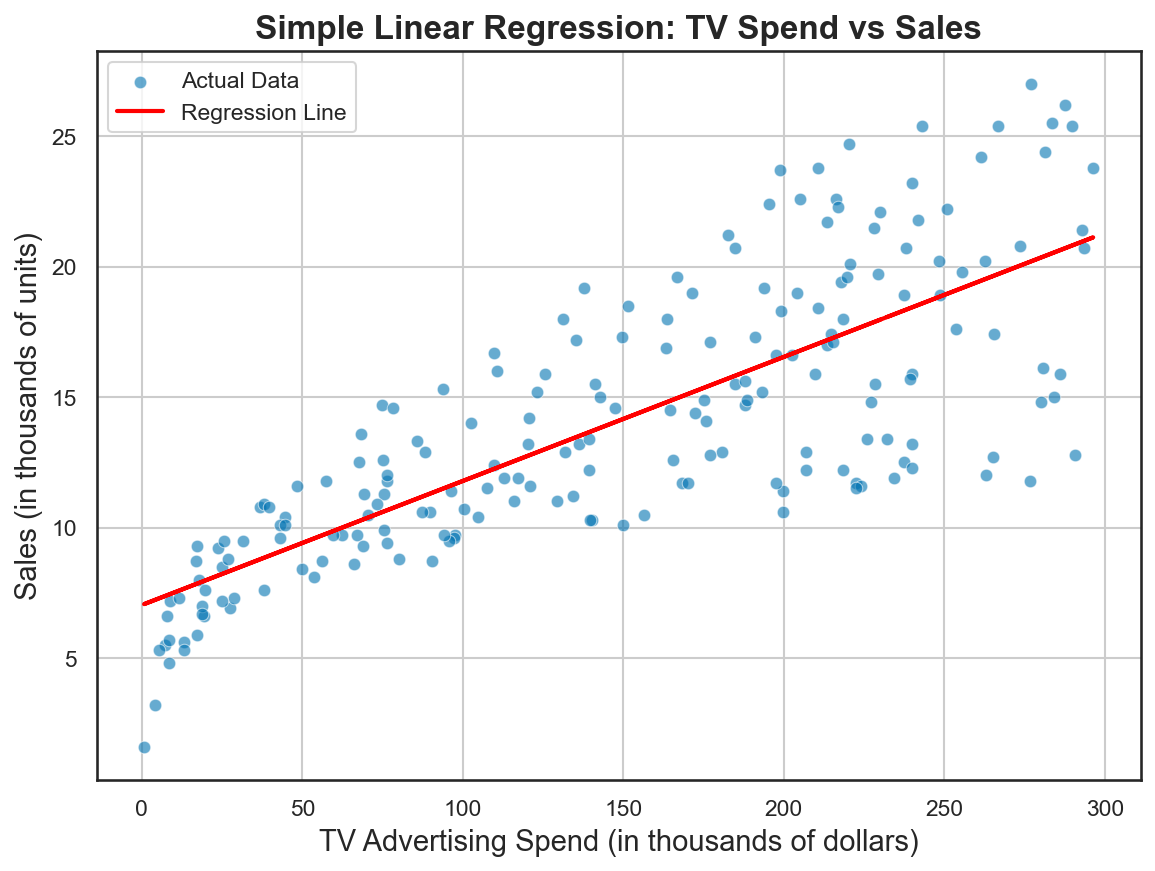

In [54]:
# Predict on the training data
y_pred = model.predict(X)

# Plot
plt.figure()
sns.scatterplot(data=sales_df, x="tv", y="sales", alpha=0.6, label="Actual Data")
plt.plot(sales_df["tv"], y_pred, color='red', linewidth=2, label="Regression Line")
plt.title("Simple Linear Regression: TV Spend vs Sales", fontsize=16, fontweight='bold')
plt.xlabel("TV Advertising Spend (in thousands of dollars)", fontsize=14)
plt.ylabel("Sales (in thousands of units)", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

---

## Summary

In this lab, we learned how to use scikit-learn's `LinearRegression` to build a Simple Linear Regression model. Here's what we covered:

| Step | What We Did | Key scikit-learn API |
|------|-------------|---------------------|
| Prepare data | Separated features (`X`) and target (`y`) | — |
| Create model | Instantiated a `LinearRegression` object | `LinearRegression()` |
| Train model | Fit the model to the data | `model.fit(X, y)` |
| Inspect parameters | Read the learned intercept and slope | `model.intercept_`, `model.coef_` |
| Predict | Used the model to predict new values | `model.predict(X_new)` |

The model tells us that TV advertising has a clear positive impact on sales. Of course, this simple model only considers one feature. In the next section, we'll learn about **Multiple Linear Regression**, which lets us incorporate more features (like Radio and Newspaper spend) into the model.

---

**Next:** [Multiple Linear Regression Theory](./05_multiple_linear_regression_theory.md)